# Lab 3 · Transfer Learning by Fine-Tuning — Teach a Pretrained Generator YOUR Symbol
**MSACL · DS301 Deep Learning · Segment 3 · Lab 3**

Someone already spent real compute training a neural network to **draw handwritten
digits**. In this lab you **download that finished model straight from the Hugging Face
Hub** — no training from scratch — and then, with a **short fine-tune on a few examples**,
teach it to draw a **brand-new symbol that you invent**.

That is the whole idea of **transfer learning** (Lecture 8): don't rebuild a big model from
nothing — take one that already knows something useful and **nudge** it toward your task with
a handful of your own examples. Here the task is generative and visual, so you can literally
*watch* the transfer happen: digits before, your symbol after.

**You fill in three short pieces**, all decisions that matter:
1. **Invent your symbol** — draw it in a little ASCII grid.
2. **The diffusion training objective** — one line, the heart of how these models learn.
3. **The fine-tune learning rate** — a real transfer-learning knob.

Everything else — the Hub download, the sampling loop, the fine-tune loop, and every plot —
runs as-is. This is a ~45-minute session (+ 10 min discussion).

## Step 0 · Setup *(runs for you)*

In [28]:
# Read and run — no need to edit.
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as nd_rotate, shift as nd_shift, zoom as nd_zoom
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler

def seed_everything(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

seed_everything(0)

# Use a GPU (Colab T4) if present, else Apple MPS, else CPU. This tiny model is fast anywhere.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Libraries ready. Device:", DEVICE)

Libraries ready. Device: mps


In [29]:
# Read and run — no need to edit.
# Download a REAL pretrained generator from the Hugging Face Hub (public, ~15 MB, no login).
# `balakrish181/ddpm-class-mnist-28` is a small (~4M-parameter) diffusion model that was
# trained to generate 28x28 handwritten MNIST digits. `from_pretrained` fetches the weights.
MODEL_ID = "balakrish181/ddpm-class-mnist-28"
unet = UNet2DModel.from_pretrained(MODEL_ID, use_safetensors=True).to(DEVICE)

# The "scheduler" is the fixed recipe of how much noise is added at each step (this checkpoint
# was trained with a plain linear noise schedule — we must match it).
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear",
                          beta_start=1e-4, beta_end=0.02, clip_sample=True)

n_params = sum(p.numel() for p in unet.parameters())
print(f"Loaded pretrained generator: {n_params:,} parameters, images are "
      f"{unet.config.in_channels}x{unet.config.sample_size}x{unet.config.sample_size}.")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loaded pretrained generator: 4,023,233 parameters, images are 1x28x28.


## Step 1 · Watch the pretrained model draw digits *(runs for you)*

A diffusion model generates a picture by starting from **pure random noise** and repeatedly
**removing a little predicted noise** until a clean image appears. The `sample` helper below
does exactly that. Let's see what this model knows how to draw right now — **handwritten
digits** — and keep these "before" pictures for the payoff at the end.

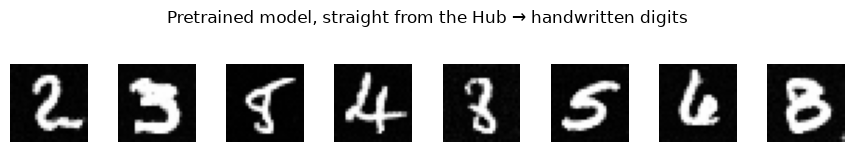

In [30]:
# Read and run — no need to edit.
@torch.no_grad()
def sample(net, n=8, steps=50, seed=0, noise=None):
    """Generate n images by denoising from random noise (a few dozen fast steps)."""
    net.eval()
    if noise is None:
        g = torch.Generator("cpu").manual_seed(seed)
        noise = torch.randn(n, 1, 28, 28, generator=g)
    x = noise.to(DEVICE)
    sc = DDIMScheduler(num_train_timesteps=1000, beta_schedule="linear",
                       beta_start=1e-4, beta_end=0.02, clip_sample=True)
    sc.set_timesteps(steps)
    for t in sc.timesteps:
        x = sc.step(net(x, t).sample, t, x).prev_sample
    return x.clip(-1, 1).cpu()

def show_row(samples, title):
    n = samples.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(1.1 * n, 1.4))
    for ax, img in zip(axes, samples):
        ax.imshow((img[0] + 1) / 2, cmap="Greys_r", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title, y=1.05)
    plt.tight_layout(); plt.show()

# Capture the "before" pictures now, BEFORE we fine-tune — these are the pretrained digits.
before_samples = sample(unet, n=8, steps=50, seed=7)
show_row(before_samples, "Pretrained model, straight from the Hub → handwritten digits")

## Step 2 · Invent your symbol — YOUR TURN ✏️ (Blank 1)

Time to invent the new thing you'll teach the model to draw. Edit the grid below: it's a list
of equal-length strings where `'#'` is **ink** and `'.'` is **blank**. Draw any simple, bold
shape — a **heart, a star, a letter, or your initial**. Keep it chunky and centered so the
model has something clear to learn (thin single-pixel lines are hard).

The shipped example is a heart — **replace it with your own** (keep all rows the same length).

In [31]:
# ---- Blank 1: draw YOUR symbol in the grid below. ----
# '#' = ink, '.' = blank. Keep every row exactly 16 characters long.
# Draw any bold, centered shape: a heart, a star, a letter, or your initial.
# (For reference, a heart's widest row looks like ".############...")
### BEGIN SOLUTION
SYMBOL = [
    "................",
    "................",
    "..###....###....",
    ".#####..#####...",
    ".############...",
    ".############...",
    ".############...",
    "..##########....",
    "...########.....",
    "....######......",
    ".....####.......",
    "......##........",
    "................",
    "................",
    "................",
    "................",
]
### END SOLUTION

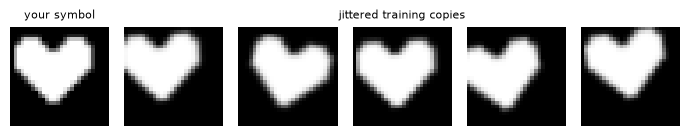

Symbol parsed: 28x28, 34% ink. Training set: (32, 1, 28, 28).


In [32]:
# Read and run — no need to edit.
# Turn your ASCII drawing into a 28x28 image, then make ~32 lightly jittered copies
# (small rotations and shifts) as a tiny training set — the "few examples" of transfer learning.

# --- sanity check on YOUR grid: catch a mis-typed drawing early, with a clear message ---
assert isinstance(SYMBOL, list) and len(SYMBOL) >= 8, \
    "SYMBOL must be a list of at least 8 rows of text"
row_lengths = {len(r) for r in SYMBOL}
assert len(row_lengths) == 1, \
    f"every row of SYMBOL must be the SAME length — got row lengths {sorted(row_lengths)}"
assert set("".join(SYMBOL)) <= {"#", "."}, \
    "use only '#' (ink) and '.' (blank) in your grid"

def parse_symbol(rows):
    grid = np.array([[1.0 if ch == '#' else 0.0 for ch in r] for r in rows], dtype=np.float32)
    # scale each axis independently so ANY rectangular grid becomes exactly 28x28
    img = np.clip(nd_zoom(grid, (28 / grid.shape[0], 28 / grid.shape[1]), order=1), 0, 1)
    return img

def make_training_set(target01, n=32, seed=0):
    rng = np.random.default_rng(seed)
    imgs = []
    for _ in range(n):
        im = nd_rotate(target01, rng.uniform(-12, 12), reshape=False, order=1)
        im = nd_shift(im, (rng.uniform(-2, 2), rng.uniform(-2, 2)), order=1)
        imgs.append(np.clip(im, 0, 1))
    arr = np.stack(imgs)[:, None]                 # (n, 1, 28, 28) in [0, 1]
    return torch.from_numpy(arr).float() * 2 - 1  # rescale to the model's [-1, 1] range

target = parse_symbol(SYMBOL)                      # 28x28 in [0, 1]
train_images = make_training_set(target).to(DEVICE)
ink_fraction = float((target > 0.5).mean())

# Show your symbol and a few jittered training copies (fun visual #2).
fig, axes = plt.subplots(1, 6, figsize=(7, 1.4))
axes[0].imshow(target, cmap="Greys_r", vmin=0, vmax=1); axes[0].set_title("your symbol", fontsize=8)
axes[0].axis("off")
for j in range(5):
    axes[j + 1].imshow((train_images[j, 0].cpu() + 1) / 2, cmap="Greys_r", vmin=0, vmax=1)
    axes[j + 1].axis("off")
axes[3].set_title("jittered training copies", fontsize=8)
plt.tight_layout(); plt.show()

# --- self-checks: do not edit ---
assert target.shape == (28, 28), f"symbol should parse to a 28x28 image, got {target.shape}"
assert target.min() >= 0.0 and target.max() <= 1.0, "pixel values must stay in [0, 1]"
assert 0.03 < ink_fraction < 0.6, (
    f"your symbol has {ink_fraction:.0%} ink — draw something bold but not the whole grid "
    "(aim for roughly 10-40% '#')")
print(f"Symbol parsed: 28x28, {ink_fraction:.0%} ink. Training set: {tuple(train_images.shape)}.")


## Step 3 · The training objective — YOUR TURN ✏️ (Blank 2)

Here is the one idea behind training every diffusion model:

> **Add a known amount of random noise to a real image, then ask the model to predict exactly
> the noise you added. Training = make the model's predicted noise match the real noise.**

The scaffold below does the mechanical parts for you: it draws random `noise`, picks random
timesteps `t`, uses the scheduler to make a `noisy` image, and asks the model for its guess
`noise_pred`. **Your one line:** score how far the prediction is from the truth using
**mean-squared error** between `noise_pred` and `noise`, and store it in `loss`.

In [33]:
def diffusion_loss(model, x0):
    # Scaffold (provided): make a noisy image and get the model's noise guess.
    noise = torch.randn_like(x0)                                   # the real noise we add
    t = torch.randint(0, 1000, (x0.shape[0],), device=x0.device)  # random noise levels
    noisy = scheduler.add_noise(x0, noise, t)                      # real image + that noise
    noise_pred = model(noisy, t).sample                           # the model's guess of the noise

    # ---- Blank 2: make the predicted noise match the real noise (mean-squared error) ----
    ### BEGIN SOLUTION
    loss = F.mse_loss(noise_pred, noise)
    ### END SOLUTION
    return loss

# --- self-check: do not edit ---
seed_everything(0)
_probe_loss = diffusion_loss(unet, train_images[:8])
assert torch.is_tensor(_probe_loss) and _probe_loss.ndim == 0, "loss must be a single scalar tensor"
assert torch.isfinite(_probe_loss) and _probe_loss.item() >= 0, "an MSE loss is finite and >= 0"
print(f"Objective checks out — loss on a probe batch: {_probe_loss.item():.4f}")

Objective checks out — loss on a probe batch: 0.0639


## Step 4 · The fine-tune learning rate — YOUR TURN ✏️ (Blank 3)

The learning rate sets how big each weight nudge is. **Rule for fine-tuning:** use a rate
**much smaller** than you would to train from scratch — you're gently *nudging* a model that
already knows how to draw, not rebuilding it. Too big and you wreck what it already learned;
too small and it never picks up your symbol. A good value here is around **`1e-4`**.

In [34]:
# ---- Blank 3: a small fine-tune learning rate (rule above: much smaller than from-scratch) ----
### BEGIN SOLUTION
FINETUNE_LR = 1e-4
### END SOLUTION

# --- self-check: do not edit ---
assert 0 < FINETUNE_LR < 1e-2, "for fine-tuning pick a small rate (0 < FINETUNE_LR < 1e-2), e.g. 1e-4"
print(f"Fine-tune learning rate: {FINETUNE_LR}")

Fine-tune learning rate: 0.0001


## Step 5 · Fine-tune the generator on your symbol *(runs for you)*

Now the transfer step: a short loop that uses **your loss** and **your learning rate** to nudge
the pretrained model toward your symbol. About **400 tiny steps** — well under a minute.

In [35]:
# Read and run — no need to edit.
seed_everything(0)
optimizer = torch.optim.Adam(unet.parameters(), lr=FINETUNE_LR)
STEPS, BATCH = 100, 16

unet.train()
t0 = time.time()
for step in range(STEPS):
    idx = torch.randint(0, train_images.shape[0], (BATCH,), device=DEVICE)
    loss = diffusion_loss(unet, train_images[idx])   # <-- your objective from Step 3
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 100 == 0 or step == STEPS - 1:
        print(f"  step {step:3d}   loss {loss.item():.4f}")
fine_tune_seconds = time.time() - t0
print(f"Fine-tune done: {STEPS} steps in {fine_tune_seconds:.0f} s.")

  step   0   loss 0.0477
  step  99   loss 0.0073
Fine-tune done: 100 steps in 6 s.


## Step 6 · The payoff — before vs after *(fun visual #3)*

Same model, same denoising loop. **Top row:** what it drew *before* (pretrained digits).
**Bottom row:** what it draws *now*, after your short fine-tune — your symbol, with natural
variation from sample to sample.

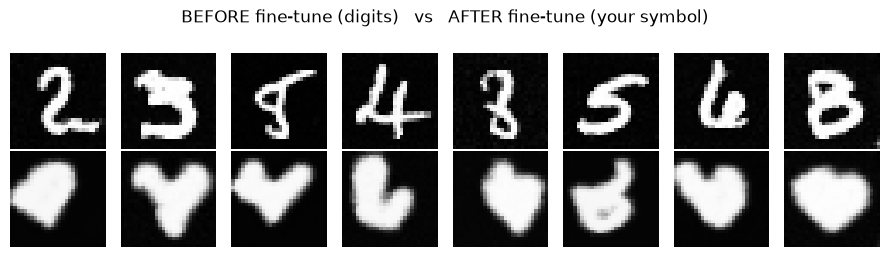

In [36]:
# Read and run — no need to edit.
after_samples = sample(unet, n=8, steps=50, seed=7)

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for j in range(8):
    axes[0, j].imshow((before_samples[j, 0] + 1) / 2, cmap="Greys_r", vmin=0, vmax=1)
    axes[1, j].imshow((after_samples[j, 0] + 1) / 2, cmap="Greys_r", vmin=0, vmax=1)
    axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("BEFORE", fontsize=9)
axes[1, 0].set_ylabel("AFTER", fontsize=9)
fig.suptitle("BEFORE fine-tune (digits)   vs   AFTER fine-tune (your symbol)")
plt.tight_layout(); plt.show()

## Step 7 · Stretch (optional) — morph the noise *(runs for you)*

The starting noise decides *which* version of your symbol comes out. Slide smoothly from one
random starting point to another and watch your symbol morph — same learned shape, different
handwriting.

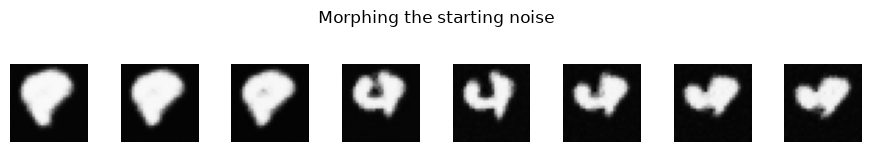

In [37]:
# Read and run — no need to edit.
g = torch.Generator("cpu").manual_seed(1); z0 = torch.randn(1, 1, 28, 28, generator=g)
g = torch.Generator("cpu").manual_seed(4); z1 = torch.randn(1, 1, 28, 28, generator=g)

alphas = np.linspace(0, 1, 8)
fig, axes = plt.subplots(1, len(alphas), figsize=(9, 1.4))
for ax, a in zip(axes, alphas):
    z = (1 - a) * z0 + a * z1
    z = z / z.std()                      # keep the noise at unit scale
    img = sample(unet, n=1, steps=50, noise=z)
    ax.imshow((img[0, 0] + 1) / 2, cmap="Greys_r", vmin=0, vmax=1); ax.axis("off")
fig.suptitle("Morphing the starting noise", y=1.05)
plt.tight_layout(); plt.show()

## Discussion D3

You just took a model **someone else trained** and, with ~32 examples and under a minute of
compute, taught it a brand-new thing — instead of training from scratch.

**Talk it over:** *Where in YOUR work is there a big pretrained model you could fine-tune on
your few labels instead of building one from nothing?* Think of a foundation model for mass
spectra or molecules, a pretrained peptide/protein model, or an imaging model — and the small,
hard-won labeled set you'd nudge it with. What would your "~32 examples" be?